# NBA All-Star Classification Project

This notebook builds a binary classifier to predict whether a player-season is labeled `ALL_STAR` using NBA season-average stats.

## 1) Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 225
sns.set_theme(style="whitegrid")

## 2) Load Data

In [2]:
DATA_PATH = Path("data") / "nba_player_season_averages_all_seasons.csv"
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 13,246
Columns: 32


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,...,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,SEASON,ALL_STAR
0,920,A.C. Green,LAL,36.0,82,67,15,0.817,23.5,2.1,...,0.6,0.6,0.2,0.3,1.5,0.2,5.0,4.0,1999-00,0
1,1920,A.J. Bramlett,CLE,23.0,8,3,5,0.375,7.6,0.5,...,0.4,0.1,0.0,0.3,1.6,0.3,1.0,-5.3,1999-00,0
2,243,Aaron McKie,PHI,27.0,82,49,33,0.598,23.8,3.0,...,1.4,1.3,0.2,0.5,2.4,0.1,8.0,0.6,1999-00,0
3,1425,Aaron Williams,WAS,28.0,81,29,52,0.358,19.1,2.9,...,1.0,0.5,1.1,0.6,2.9,0.2,7.6,0.4,1999-00,0
4,228,Adam Keefe,UTA,30.0,62,41,21,0.661,9.8,0.9,...,0.7,0.3,0.2,0.3,1.5,0.1,2.2,-0.6,1999-00,0


In [3]:
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(10))

target_rate = df["ALL_STAR"].mean()
print(f"All-Star positive rate: {target_rate:.3%}")

<class 'pandas.DataFrame'>
RangeIndex: 13246 entries, 0 to 13245
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PLAYER_ID          13246 non-null  int64  
 1   PLAYER_NAME        13246 non-null  str    
 2   TEAM_ABBREVIATION  13246 non-null  str    
 3   AGE                13246 non-null  float64
 4   GP                 13246 non-null  int64  
 5   W                  13246 non-null  int64  
 6   L                  13246 non-null  int64  
 7   W_PCT              13246 non-null  float64
 8   MIN                13246 non-null  float64
 9   FGM                13246 non-null  float64
 10  FGA                13246 non-null  float64
 11  FG_PCT             13246 non-null  float64
 12  FG3M               13246 non-null  float64
 13  FG3A               13246 non-null  float64
 14  FG3_PCT            13246 non-null  float64
 15  FTM                13246 non-null  float64
 16  FTA                13246 non-null

None

PLAYER_ID            0
PLAYER_NAME          0
TEAM_ABBREVIATION    0
AGE                  0
GP                   0
W                    0
L                    0
W_PCT                0
MIN                  0
FGM                  0
dtype: int64

All-Star positive rate: 4.922%


## 3) Class Balance and Season Distribution

,SEASON,total_players,all_stars,rate
0,1999-00,439,24,0.054670
1,2000-01,441,24,0.054422
2,2001-02,440,23,0.052273
3,2002-03,428,24,0.056075
4,2003-04,442,24,0.054299


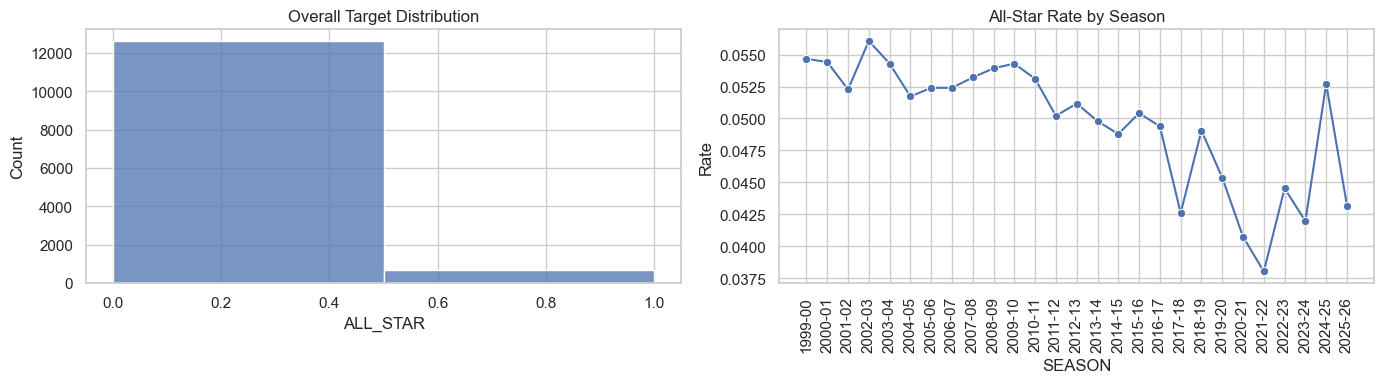

In [4]:
season_summary = (
    df.groupby("SEASON")["ALL_STAR"]
    .agg(total_players="count", all_stars="sum", rate="mean")
    .reset_index()
)
display(season_summary.head())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["ALL_STAR"], bins=2, ax=ax[0])
ax[0].set_title("Overall Target Distribution")
ax[0].set_xlabel("ALL_STAR")

sns.lineplot(data=season_summary, x="SEASON", y="rate", marker="o", ax=ax[1])
ax[1].set_title("All-Star Rate by Season")
ax[1].set_xlabel("SEASON")
ax[1].set_ylabel("Rate")
ax[1].tick_params(axis="x", rotation=90)

plt.tight_layout()

## 4) Feature Set and Temporal Split

In [5]:
# Hold out recent seasons as test set for forward-looking evaluation.
TEST_START_SEASON = "2018-19"

exclude_cols = ["ALL_STAR", "PLAYER_ID", "PLAYER_NAME", "SEASON", "TEAM_ABBREVIATION"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y = df["ALL_STAR"].astype(int).copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

train_mask = df["SEASON"] < TEST_START_SEASON
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
meta_train = df.loc[train_mask, ["PLAYER_NAME", "SEASON", "PTS", "MIN"]].reset_index(drop=True)
meta_test = df.loc[test_mask, ["PLAYER_NAME", "SEASON", "PTS", "MIN"]].reset_index(drop=True)

print("Train rows:", len(X_train), "| Test rows:", len(X_test))
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))

Train rows: 8783 | Test rows: 4463
Train positive rate: 0.0517
Test positive rate: 0.0444


## 5) Baselines and Candidate Models

In [6]:
numeric_features = X_train.columns.tolist()

numeric_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

logreg_pipeline = Pipeline(
    steps=[
        ("prep", ColumnTransformer([("num", numeric_preprocess, numeric_features)], remainder="drop")),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]
)

gb_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]
)

models = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logreg": logreg_pipeline,
    "random_forest": rf_pipeline,
    "grad_boost": gb_pipeline,
}

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

cv_rows = []
for name, model in models.items():
    results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")
    cv_rows.append({
        "model": name,
        "cv_roc_auc": np.mean(results["test_roc_auc"]),
        "cv_avg_precision": np.mean(results["test_avg_precision"]),
        "cv_f1": np.mean(results["test_f1"]),
        "cv_precision": np.mean(results["test_precision"]),
        "cv_recall": np.mean(results["test_recall"]),
    })

cv_summary = pd.DataFrame(cv_rows).sort_values("cv_roc_auc", ascending=False)
cv_summary

,model,cv_roc_auc,cv_avg_precision,cv_f1,cv_precision,cv_recall
1,logreg,0.988145,0.818124,0.637799,0.478065,0.960391
2,random_forest,0.986804,0.809828,0.709741,0.765623,0.667375
3,grad_boost,0.985417,0.799090,0.706668,0.759945,0.663004
0,dummy,0.500000,0.051691,0.000000,0.000000,0.000000


## 6) Holdout Test Evaluation

In [8]:
best_model_name = cv_summary.iloc[0]["model"]
best_model = models[best_model_name]

# Use training-only CV scores to choose threshold without peeking at holdout labels.
if hasattr(best_model, "predict_proba"):
    train_cv_scores = cross_val_predict(
        best_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
else:
    train_cv_scores = cross_val_predict(
        best_model, X_train, y_train, cv=cv, method="decision_function", n_jobs=-1
    )

prec_train, rec_train, thresholds_train = precision_recall_curve(y_train, train_cv_scores)
f1_train = (2 * prec_train * rec_train) / (prec_train + rec_train + 1e-9)
best_idx = int(np.nanargmax(f1_train[:-1])) if len(thresholds_train) > 0 else 0
opt_threshold = thresholds_train[best_idx] if len(thresholds_train) > 0 else 0.5

best_model.fit(X_train, y_train)

if hasattr(best_model, "predict_proba"):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)

y_pred_default = (y_score >= 0.5).astype(int)
y_pred_opt = (y_score >= opt_threshold).astype(int)

print(f"Best model from CV: {best_model_name}")
print(f"Holdout ROC-AUC: {roc_auc_score(y_test, y_score):.4f}")
print(f"Holdout Avg Precision: {average_precision_score(y_test, y_score):.4f}")
print(f"Optimal threshold (chosen from training CV): {opt_threshold:.4f}")

print("\nClassification report @ threshold 0.50")
print(classification_report(y_test, y_pred_default, digits=3))

print("\nClassification report @ optimized threshold")
print(classification_report(y_test, y_pred_opt, digits=3))

Best model from CV: logreg
Holdout ROC-AUC: 0.9760
Holdout Avg Precision: 0.7200
Optimal threshold (chosen from training CV): 0.8747

Classification report @ threshold 0.50
              precision    recall  f1-score   support

           0      0.997     0.935     0.965      4265
           1      0.403     0.949     0.566       198

    accuracy                          0.935      4463
   macro avg      0.700     0.942     0.766      4463
weighted avg      0.971     0.935     0.947      4463


Classification report @ optimized threshold
              precision    recall  f1-score   support

           0      0.995     0.966     0.980      4265
           1      0.552     0.889     0.681       198

    accuracy                          0.963      4463
   macro avg      0.773     0.928     0.831      4463
weighted avg      0.975     0.963     0.967      4463



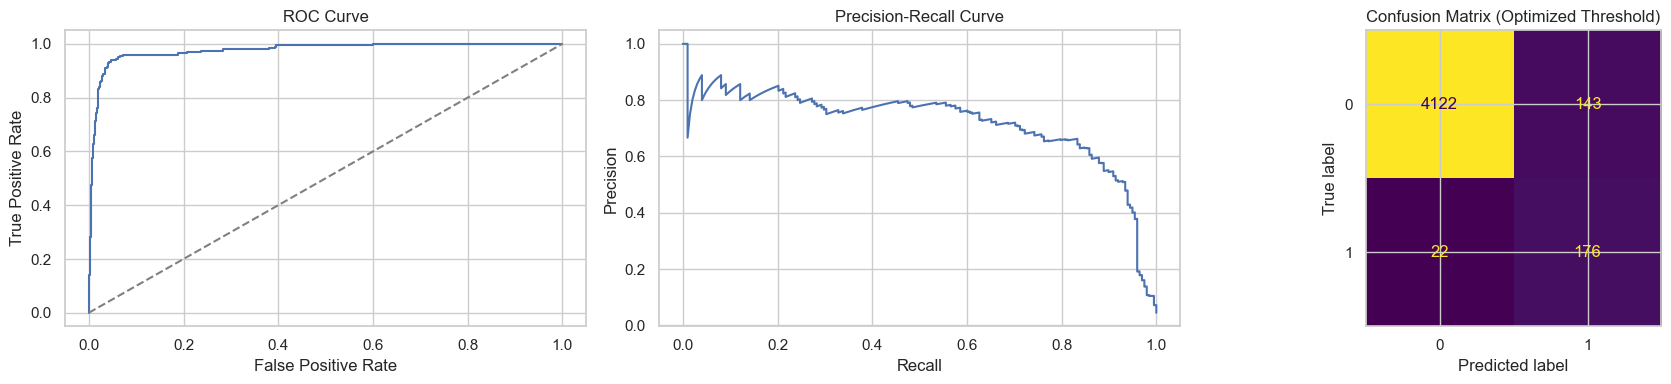

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

fpr, tpr, _ = roc_curve(y_test, y_score)
ax[0].plot(fpr, tpr, label="Model")
ax[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
ax[0].set_title("ROC Curve")
ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")

prec, rec, _ = precision_recall_curve(y_test, y_score)
ax[1].plot(rec, prec, label="PR")
ax[1].set_title("Precision-Recall Curve")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")

cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm).plot(ax=ax[2], colorbar=False)
ax[2].set_title("Confusion Matrix (Optimized Threshold)")

plt.tight_layout()

## 7) Per-Season Performance on Holdout

In [ ]:
season_eval = pd.DataFrame({
    "SEASON": df.loc[test_mask, "SEASON"].values,
    "y_true": y_test.values,
    "y_score": y_score,
    "y_pred": y_pred_opt,
})

season_metrics = (
    season_eval.groupby("SEASON")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "all_stars": int(g["y_true"].sum()),
        "f1": f1_score(g["y_true"], g["y_pred"], zero_division=0),
        "avg_score": g["y_score"].mean(),
    }))
    .reset_index()
)

season_metrics

,SEASON,n,all_stars,f1,avg_score
0,2018-19,530.0,26.0,0.761905,0.108440
1,2019-20,529.0,24.0,0.750000,0.107449
2,2020-21,540.0,22.0,0.689655,0.107294
3,2021-22,605.0,23.0,0.655738,0.101974
4,2022-23,539.0,24.0,0.676471,0.125204
5,2023-24,572.0,24.0,0.685714,0.118386
6,2024-25,569.0,30.0,0.545455,0.123698
7,2025-26,579.0,25.0,0.718750,0.109289


## 8) Model Interpretation and Error Analysis

In [ ]:
# Feature importance for best model if available.
if best_model_name == "logreg":
    coefs = best_model.named_steps["model"].coef_[0]
    imp = pd.DataFrame({"feature": numeric_features, "importance": coefs})
    imp = imp.sort_values("importance", ascending=False)
    display(imp.head(10))
    display(imp.tail(10))
elif best_model_name == "random_forest":
    imps = best_model.named_steps["model"].feature_importances_
    imp = pd.DataFrame({"feature": numeric_features, "importance": imps})
    display(imp.sort_values("importance", ascending=False).head(20))
else:
    print("Feature importance is not directly available for this model pipeline.")

,feature,importance
2,W,1.291847
7,FGA,0.967585
18,AST,0.771078
25,PTS,0.742888
0,AGE,0.721134
12,FTM,0.710673
6,FGM,0.678078
15,OREB,0.622795
21,BLK,0.553696
1,GP,0.477328


,feature,importance
14,FT_PCT,0.209120
11,FG3_PCT,0.092333
13,FTA,0.072369
24,PFD,-0.034959
20,STL,-0.136185
10,FG3A,-0.224005
22,BLKA,-0.416940
4,W_PCT,-0.506666
3,L,-0.597713
23,PF,-0.699817


In [ ]:
error_df = meta_test.copy()
error_df["y_true"] = y_test.values
error_df["y_score"] = y_score
error_df["y_pred"] = y_pred_opt

false_positives = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)].sort_values("y_score", ascending=False)
false_negatives = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)].sort_values("y_score", ascending=True)

print("Top false positives:")
display(false_positives.head(10))

print("Top false negatives:")
display(false_negatives.head(10))

Top false positives:


,PLAYER_NAME,SEASON,PTS,MIN,y_true,y_score,y_pred
3026,Joel Embiid,2023-24,34.7,33.6,0,0.999999,1
3495,Giannis Antetokounmpo,2024-25,30.4,34.2,0,0.999994,1
4383,Shai Gilgeous-Alexander,2025-26,31.3,33.3,0,0.999986,1
1945,Kevin Durant,2021-22,29.9,37.2,0,0.999977,1
1319,Joel Embiid,2020-21,28.5,31.1,0,0.999956,1
2512,Kevin Durant,2022-23,29.1,35.6,0,0.999954,1
3673,LeBron James,2024-25,24.4,34.9,0,0.999944,1
2226,Anthony Davis,2022-23,25.9,34.0,0,0.999842,1
3343,Anthony Davis,2024-25,24.7,33.4,0,0.999805,1
2675,Stephen Curry,2022-23,29.4,34.7,0,0.999788,1


Top false negatives:


,PLAYER_NAME,SEASON,PTS,MIN,y_true,y_score,y_pred
3794,Ryan Dunn,2024-25,6.9,19.1,1,0.000030,0
3839,Trayce Jackson-Davis,2024-25,6.6,15.6,1,0.000512,0
131,Dirk Nowitzki,2018-19,7.3,15.6,1,0.000536,0
3426,Dalton Knecht,2024-25,9.1,19.2,1,0.000639,0
3575,Jaylen Wells,2024-25,10.4,25.9,1,0.002730,0
3652,Keyonte George,2024-25,16.8,31.5,1,0.007213,0
3814,Stephon Castle,2024-25,14.7,26.7,1,0.012928,0
3878,Zach Edey,2024-25,9.2,21.5,1,0.018758,0
1620,Andrew Wiggins,2021-22,17.2,31.9,1,0.425069,0
4321,Norman Powell,2025-26,21.9,30.0,1,0.490871,0


## 9) Caveat and Next Step

This model uses full-season averages to predict `ALL_STAR`, but All-Star selection occurs during the season. Treat this as post-hoc classification quality, not strict pre-selection forecasting.

## 10) Ablation: Team Context Features

In [ ]:
def build_model_pipeline(model_name, feature_list):
    if model_name == "logreg":
        prep = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )
        return Pipeline(
            steps=[
                ("prep", ColumnTransformer([("num", prep, feature_list)], remainder="drop")),
                (
                    "model",
                    LogisticRegression(
                        max_iter=5000,
                        class_weight="balanced",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        )
    if model_name == "random_forest":
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=500,
                        max_depth=None,
                        min_samples_leaf=2,
                        class_weight="balanced_subsample",
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        )
    if model_name == "grad_boost":
        return Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
            ]
        )
    return DummyClassifier(strategy="most_frequent")


team_context_cols = [c for c in ["W", "L", "W_PCT"] if c in feature_cols]
ablation_feature_sets = {
    "with_team_context": feature_cols,
    "without_team_context": [c for c in feature_cols if c not in team_context_cols],
}

ablation_rows = []
for setting, cols in ablation_feature_sets.items():
    X_train_set = df.loc[train_mask, cols].apply(pd.to_numeric, errors="coerce")
    X_test_set = df.loc[test_mask, cols].apply(pd.to_numeric, errors="coerce")

    model = build_model_pipeline(best_model_name, cols)
    model.fit(X_train_set, y_train)

    if hasattr(model, "predict_proba"):
        train_scores = model.predict_proba(X_train_set)[:, 1]
        y_score_set = model.predict_proba(X_test_set)[:, 1]
    else:
        train_scores = model.decision_function(X_train_set)
        y_score_set = model.decision_function(X_test_set)

    p_train, r_train, th_train = precision_recall_curve(y_train, train_scores)
    f1_train_vals = (2 * p_train * r_train) / (p_train + r_train + 1e-9)
    idx = int(np.nanargmax(f1_train_vals[:-1])) if len(th_train) > 0 else 0
    threshold = th_train[idx] if len(th_train) > 0 else 0.5

    y_pred_set = (y_score_set >= threshold).astype(int)
    report = classification_report(y_test, y_pred_set, output_dict=True, zero_division=0)

    ablation_rows.append({
        "setting": setting,
        "n_features": len(cols),
        "threshold": float(threshold),
        "roc_auc": roc_auc_score(y_test, y_score_set),
        "avg_precision": average_precision_score(y_test, y_score_set),
        "class1_precision": report["1"]["precision"],
        "class1_recall": report["1"]["recall"],
        "class1_f1": report["1"]["f1-score"],
        "accuracy": report["accuracy"],
    })

ablation_results = pd.DataFrame(ablation_rows).sort_values("class1_f1", ascending=False)
ablation_results

,setting,n_features,threshold,roc_auc,avg_precision,class1_precision,class1_recall,class1_f1,accuracy
1,without_team_context,24,0.902065,0.975872,0.713650,0.570033,0.883838,0.693069,0.965270
0,with_team_context,27,0.886921,0.976030,0.719998,0.565916,0.888889,0.691552,0.964822


## 11) Submission-Ready Conclusions

In [ ]:
best_cv_row = cv_summary.iloc[0]
best_ablation_row = ablation_results.iloc[0]

print("Final Project Summary")
print("-" * 60)
print(f"Dataset size: {len(df):,} player-seasons across {df['SEASON'].nunique()} seasons")
print(f"Target prevalence (ALL_STAR=1): {df['ALL_STAR'].mean():.2%}")
print(f"Primary model selected by CV ROC-AUC: {best_model_name}")
print(f"CV ROC-AUC (best model): {best_cv_row['cv_roc_auc']:.4f}")
print(f"Holdout ROC-AUC: {roc_auc_score(y_test, y_score):.4f}")
print(f"Holdout Average Precision: {average_precision_score(y_test, y_score):.4f}")
print(f"Operational threshold (training-CV selected): {opt_threshold:.4f}")

report_opt = classification_report(y_test, y_pred_opt, output_dict=True, zero_division=0)
print("\nHoldout class-1 (All-Star) performance at operational threshold:")
print(f"- Precision: {report_opt['1']['precision']:.3f}")
print(f"- Recall: {report_opt['1']['recall']:.3f}")
print(f"- F1: {report_opt['1']['f1-score']:.3f}")

print("\nAblation takeaway (same model family):")
print(f"- Best feature setting: {best_ablation_row['setting']}")
print(f"- Class-1 F1 under best ablation: {best_ablation_row['class1_f1']:.3f}")
print(f"- ROC-AUC under best ablation: {best_ablation_row['roc_auc']:.4f}")

print("\nInterpretation:")
print("- The classifier separates All-Star vs non-All-Star seasons strongly (high ROC-AUC).")
print("- Threshold tuning substantially improves minority-class balance vs default 0.50 threshold.")
print("- This is a post-hoc classification study because labels are All-Star outcomes while features are full-season averages.")

display(ablation_results)

Final Project Summary
------------------------------------------------------------
Dataset size: 13,246 player-seasons across 27 seasons
Target prevalence (ALL_STAR=1): 4.92%
Primary model selected by CV ROC-AUC: logreg
CV ROC-AUC (best model): 0.9881
Holdout ROC-AUC: 0.9760
Holdout Average Precision: 0.7200
Operational threshold (training-CV selected): 0.8747

Holdout class-1 (All-Star) performance at operational threshold:
- Precision: 0.552
- Recall: 0.889
- F1: 0.681

Ablation takeaway (same model family):
- Best feature setting: without_team_context
- Class-1 F1 under best ablation: 0.693
- ROC-AUC under best ablation: 0.9759

Interpretation:
- The classifier separates All-Star vs non-All-Star seasons strongly (high ROC-AUC).
- Threshold tuning substantially improves minority-class balance vs default 0.50 threshold.
- This is a post-hoc classification study because labels are All-Star outcomes while features are full-season averages.


,setting,n_features,threshold,roc_auc,avg_precision,class1_precision,class1_recall,class1_f1,accuracy
1,without_team_context,24,0.902065,0.975872,0.713650,0.570033,0.883838,0.693069,0.965270
0,with_team_context,27,0.886921,0.976030,0.719998,0.565916,0.888889,0.691552,0.964822
